🏥 Medical Insurance Cost Prediction
Goal: Predict how much a patient will be charged for medical insurance based on age, sex, BMI, smoking status, region, and number of children.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error,r2_score

In [2]:
df = pd.read_csv("D:\\Project Files of Softwares\\GitHub Repository\\Machine_Learning\\DataSets\\insurance.csv")

In [3]:
print(df.head())
print(df.info())
print(df.describe())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
               age          bmi     children       charges
count  1338.000000  1338.000000 

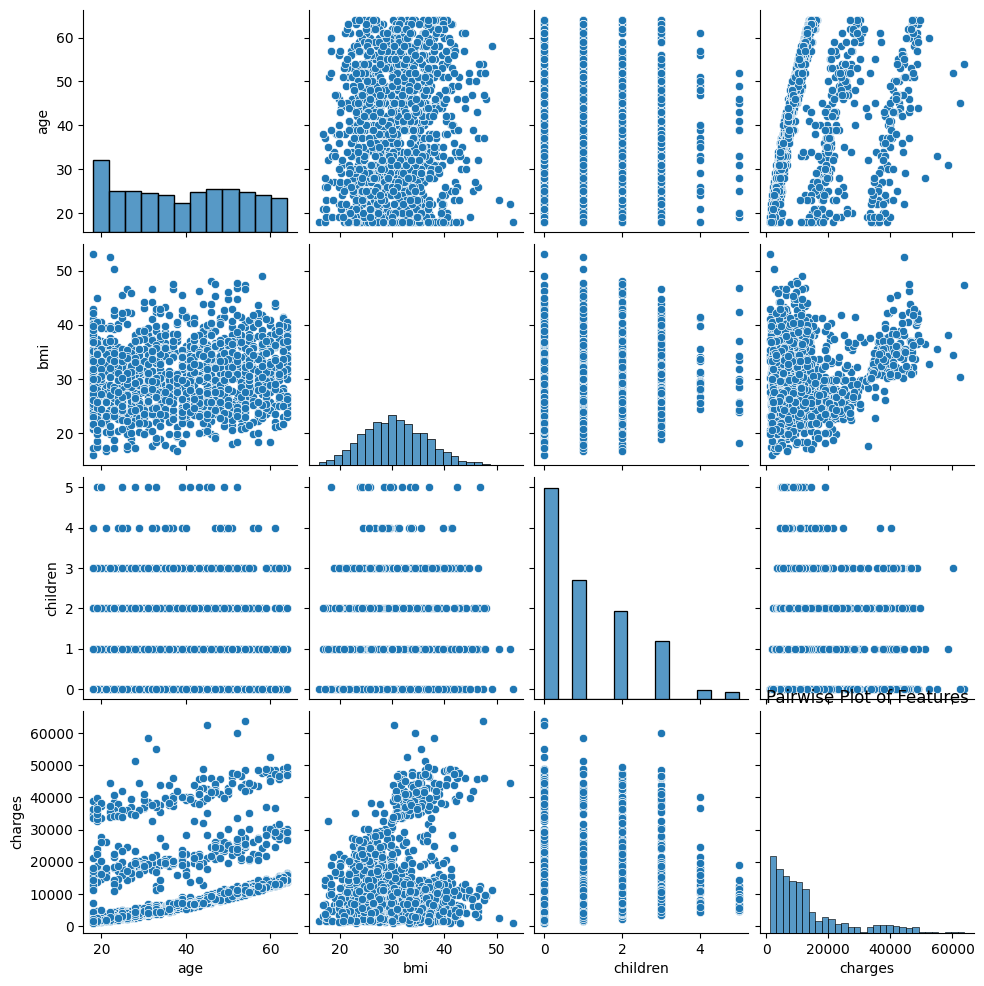

In [4]:
sns.pairplot(df)
plt.title("Pairwise Plot of Features")
plt.show()

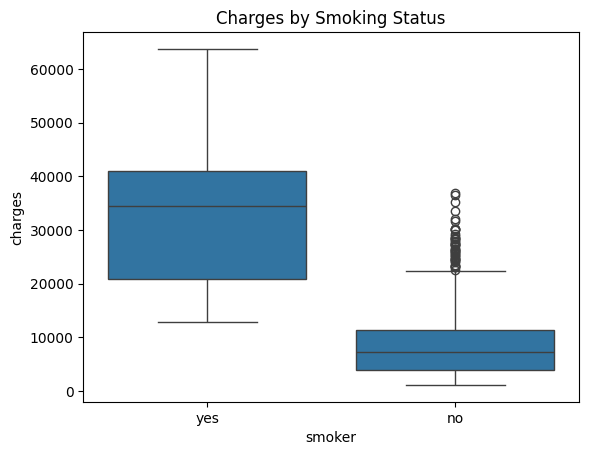

In [5]:
sns.boxplot(x='smoker',y='charges',data=df)
plt.title("Charges by Smoking Status")
plt.show()

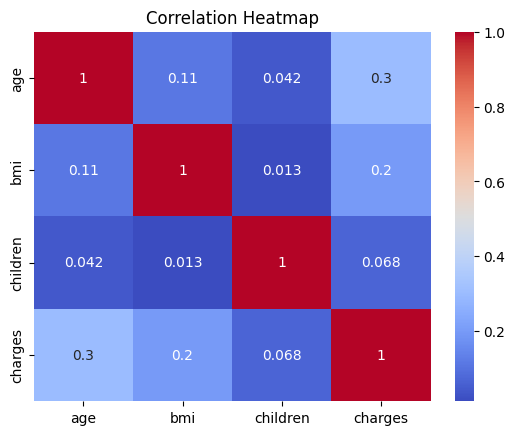

In [6]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#Data Preprocessing

# Encode categorical variables

In [7]:
categorical_cols = ['sex','smoker','region']
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Scale numerical features

In [8]:
numerical_cols = ['age','bmi','children']
scaler = StandardScaler()
df[numerical_cols]=scaler.fit_transform(df[numerical_cols])

In [9]:
X=df.drop(columns='charges')
y=df['charges']

In [10]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Model Tranning

In [11]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

# Evalution

In [12]:
y_pred = model.predict(X_test)

In [13]:
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
print("MEAN SQUARED ERROR:",mse)
print("R2_Score:",r2)

MEAN SQUARED ERROR: 33635210.43117841
R2_Score: 0.7833463107364538


# Visualization of Actual vs Predicted

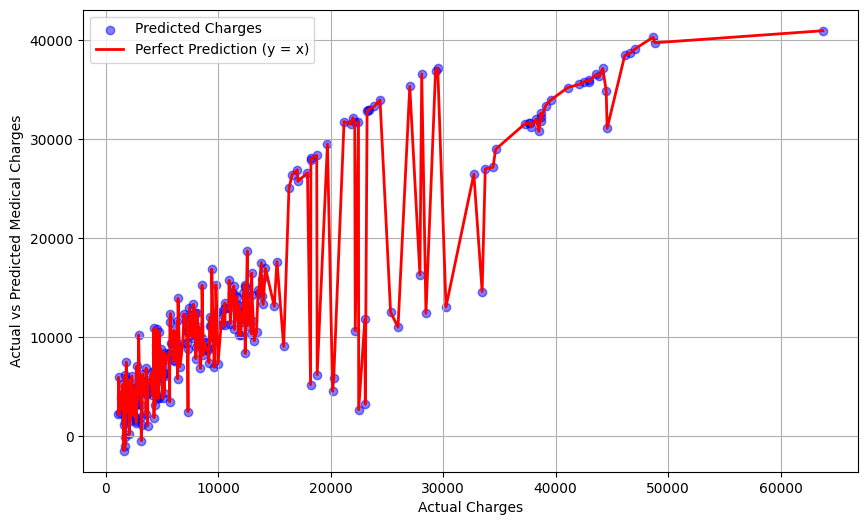

In [14]:
plt.figure(figsize=(10,6))
sorted_indices = y_test.argsort()
x_sorted = y_test.iloc[sorted_indices].values
y_sorted = y_pred[sorted_indices]

plt.scatter(x_sorted,y_sorted,color='blue',label='Predicted Charges',alpha=0.5)
plt.plot(x_sorted,y_sorted,color='red',label='Perfect Prediction (y = x)',linewidth=2)
plt.xlabel('Actual Charges')
plt.ylabel('Actual vs Predicted Medical Charges')
plt.legend()
plt.grid(True)
plt.show()